# Filtro anti-haters v4 — DistilBERT (fine-tuning) a confronto con la BiLSTM

**Dove eravamo arrivati.** Nel Master il vincolo era "niente Transformer": la soluzione migliore (v3, BiLSTM + Word2Vec)
arriva a ROC AUC 0.980 e F1 micro 0.736, ma resta un divario di ~6 punti di F1 tra commenti **con** e **senza** negazione.
L'esperimento v3 ha mostrato che correzioni "classiche" (marcatura delle negazioni, fastText) non lo riducono:
il limite è negli **embedding statici**, un vettore per parola indipendente dal contesto.

**Qui il vincolo cade.** Si fa il fine-tuning di **DistilBERT** (`distilbert-base-uncased`, 66M parametri), un Transformer
che produce rappresentazioni **contestuali**: `offensive` ha un vettore diverso in *"you are offensive"* e in *"I don't find this offensive"*.

**Confronto equo con la BiLSTM:** stesso dataset, **stesso split** (stessi indici train/val/test), stessa scelta delle
soglie per classe sul validation set, stesse metriche sul test set.

In [1]:
%pip install -q transformers

In [2]:
import os, re, json, time, shutil, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

DATASET_DRIVE_PATH = '/content/drive/MyDrive/Filter_Toxic_Comments_dataset.csv'
V3_RESULTS = '/content/drive/MyDrive/modelli_addestrati/filtro_anti_haters_v3/risultati_esperimenti.csv'
DRIVE_FOLDER = '/content/drive/MyDrive/modelli_addestrati/filtro_anti_haters_v4_distilbert'
WORK_DIR = '/tmp/filtro_v4'
MODEL_NAME = 'distilbert-base-uncased'
SAMPLE_FRAC = 1.0

LABEL_COLUMNS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
MAX_LEN     = 128       # token WordPiece: copre per intero ~85% dei commenti
BATCH_SIZE  = 32
EPOCHS      = 2         # per il fine-tuning di un Transformer 2-3 epoche bastano
LR          = 3e-5
WARMUP      = 0.06
RANDOM_STATE = 42

os.makedirs(WORK_DIR, exist_ok=True)
torch.manual_seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import drive
    IN_COLAB = True
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False
print('Device:', DEVICE, torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

Mounted at /content/drive
Device: cuda Tesla T4


## 1. Dati e split
Lo split riproduce esattamente quello della v3 (stesso `random_state` sugli stessi indici), così le metriche sono confrontabili.
Al Transformer si passa il testo quasi grezzo: la sua tokenizzazione WordPiece gestisce maiuscole, punteggiatura e parole rare.

In [3]:
df = pd.read_csv(DATASET_DRIVE_PATH, on_bad_lines='skip').dropna(subset=['comment_text']).reset_index(drop=True)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

idx_train, idx_temp = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.5, random_state=RANDOM_STATE)

texts = (df['comment_text'].str.replace(r'https?://\S+|www\.\S+', ' ', regex=True)
                           .str.replace(r'\s+', ' ', regex=True).str.strip())
Y = df[LABEL_COLUMNS].values.astype('float32')

# Stessa definizione di "commento con negazione" della v3
NEGATIONS = ['not', 'no', 'never', 'nothing', 'nobody', 'none', 'nor', 'without', 'dont', 'doesnt', 'didnt',
             'isnt', 'arent', 'wasnt', 'werent', 'havent', 'hasnt', 'hadnt', 'cant', 'cannot', 'couldnt',
             'wont', 'wouldnt', 'shouldnt', 'aint']
neg_re = re.compile(r'\b(?:' + '|'.join(NEGATIONS) + r')\b')
no_apos = df['comment_text'].str.lower().str.replace(r"[’`']", '', regex=True)
has_neg_test = no_apos.loc[idx_test].str.contains(neg_re).values
print(f'Train {len(idx_train):,} | Val {len(idx_val):,} | Test {len(idx_test):,} (con negazione: {has_neg_test.mean():.1%})')

Train 127,656 | Val 15,957 | Test 15,958 (con negazione: 54.0%)


## 2. Tokenizzazione

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class CommentsDataset(Dataset):
    def __init__(self, idx):
        enc = tokenizer(texts.loc[idx].tolist(), truncation=True, max_length=MAX_LEN, padding=False)
        self.ids, self.labels = enc['input_ids'], Y[idx]
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        return self.ids[i], self.labels[i]

def collate(batch):
    # padding dinamico: ogni batch è lungo quanto il suo commento più lungo (più veloce del padding fisso)
    ids, labels = zip(*batch)
    width = max(len(x) for x in ids)
    input_ids = torch.full((len(ids), width), tokenizer.pad_token_id, dtype=torch.long)
    attention = torch.zeros((len(ids), width), dtype=torch.long)
    for i, x in enumerate(ids):
        input_ids[i, :len(x)] = torch.tensor(x); attention[i, :len(x)] = 1
    return input_ids, attention, torch.tensor(np.array(labels))

t0 = time.time()
ds_train, ds_val, ds_test = CommentsDataset(idx_train), CommentsDataset(idx_val), CommentsDataset(idx_test)
lengths = np.array([len(x) for x in ds_train.ids])
print(f'Tokenizzazione: {time.time()-t0:.0f}s | commenti troncati a {MAX_LEN} token: {(lengths >= MAX_LEN).mean():.1%}')

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
dl_val   = DataLoader(ds_val, batch_size=128, collate_fn=collate)
dl_test  = DataLoader(ds_test, batch_size=128, collate_fn=collate)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizzazione: 55s | commenti troncati a 128 token: 19.2%


## 3. Fine-tuning
DistilBERT pre-addestrato + una testa di classificazione a 6 uscite (sigmoid, `BCEWithLogitsLoss`).
AdamW con warmup e decadimento lineare del learning rate, precisione mista (fp16) sulla GPU.
A fine di ogni epoca si valuta la ROC AUC sul validation set e si tiene il modello migliore.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABEL_COLUMNS), problem_type='multi_label_classification').to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = EPOCHS * len(dl_train)
scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP * total_steps), total_steps)
use_amp = DEVICE == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
loss_fn = torch.nn.BCEWithLogitsLoss()

@torch.no_grad()
def predict_proba(dl):
    model.eval(); out = []
    for input_ids, attention, _ in dl:
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            logits = model(input_ids=input_ids.to(DEVICE), attention_mask=attention.to(DEVICE)).logits
        out.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(out)

def macro_auc(y, p):
    return np.mean([roc_auc_score(y[:, j], p[:, j]) for j in range(y.shape[1]) if 0 < y[:, j].sum() < len(y)])

best_auc, history = -1, []
BEST_DIR = os.path.join(WORK_DIR, 'best')
for epoch in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); running = 0.0
    for step, (input_ids, attention, labels) in enumerate(dl_train, 1):
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            logits = model(input_ids=input_ids.to(DEVICE), attention_mask=attention.to(DEVICE)).logits
        loss = loss_fn(logits.float(), labels.to(DEVICE))
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        running += loss.item()
        if step % 1000 == 0:
            print(f'  epoca {epoch} · step {step}/{len(dl_train)} · loss {running/step:.4f} · {time.time()-t0:.0f}s')
    val_auc = macro_auc(Y[idx_val], predict_proba(dl_val))
    history.append({'epoca': epoch, 'train_loss': running / len(dl_train), 'val_auc': val_auc, 'minuti': (time.time()-t0)/60})
    print(f'Epoca {epoch}: train loss {running/len(dl_train):.4f} · val ROC AUC {val_auc:.4f} · {(time.time()-t0)/60:.1f} min')
    if val_auc > best_auc:
        best_auc = val_auc
        model.save_pretrained(BEST_DIR); tokenizer.save_pretrained(BEST_DIR)
        print('  → modello migliore salvato')

model = AutoModelForSequenceClassification.from_pretrained(BEST_DIR).to(DEVICE)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoca 1 · step 1000/3990 · loss 0.1246 · 106s
  epoca 1 · step 2000/3990 · loss 0.0853 · 218s
  epoca 1 · step 3000/3990 · loss 0.0711 · 328s
Epoca 1: train loss 0.0631 · val ROC AUC 0.9896 · 7.6 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → modello migliore salvato
  epoca 2 · step 1000/3990 · loss 0.0320 · 111s
  epoca 2 · step 2000/3990 · loss 0.0327 · 223s
  epoca 2 · step 3000/3990 · loss 0.0324 · 334s
Epoca 2: train loss 0.0321 · val ROC AUC 0.9911 · 7.7 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  → modello migliore salvato


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## 4. Valutazione e confronto con la BiLSTM

In [6]:
def tune_thresholds(y_true, y_proba, grid=np.round(np.arange(0.05, 0.96, 0.01), 2)):
    return np.array([grid[int(np.argmax([f1_score(y_true[:, j], y_proba[:, j] >= t, zero_division=0) for t in grid]))]
                     for j in range(y_true.shape[1])])

thr = tune_thresholds(Y[idx_val], predict_proba(dl_val))
p = predict_proba(dl_test)
yt = Y[idx_test].astype(int); pred = (p >= thr).astype(int)
row = {'esperimento': 'E · DistilBERT (fine-tuning)',
       'ROC AUC': macro_auc(yt, p),
       'F1 micro': f1_score(yt, pred, average='micro', zero_division=0),
       'F1 macro': f1_score(yt, pred, average='macro', zero_division=0),
       'F1 con negazione': f1_score(yt[has_neg_test], pred[has_neg_test], average='micro', zero_division=0),
       'F1 senza negazione': f1_score(yt[~has_neg_test], pred[~has_neg_test], average='micro', zero_division=0)}
row.update({f'F1 {l}': f1_score(yt[:, j], pred[:, j], zero_division=0) for j, l in enumerate(LABEL_COLUMNS)})

cols = ['ROC AUC', 'F1 micro', 'F1 macro', 'F1 con negazione', 'F1 senza negazione'] + [f'F1 {l}' for l in LABEL_COLUMNS]
frames = []
if os.path.exists(V3_RESULTS):
    v3 = pd.read_csv(V3_RESULTS)
    frames.append(v3[v3['esperimento'].str.startswith('A ')].assign(esperimento='A · BiLSTM + Word2Vec (v3)'))
frames.append(pd.DataFrame([row]))
comp = pd.concat(frames).set_index('esperimento')[cols]
display(comp.style.format('{:.3f}').highlight_max(color='#2e7d32'))

,ROC AUC,F1 micro,F1 macro,F1 con negazione,F1 senza negazione,F1 toxic,F1 severe_toxic,F1 obscene,F1 threat,F1 insult,F1 identity_hate
esperimento,,,,,,,,,,,
A · BiLSTM + Word2Vec (v3),0.980,0.736,0.613,0.700,0.760,0.774,0.512,0.810,0.405,0.730,0.445
E · DistilBERT (fine-tuning),0.992,0.790,0.683,0.747,0.818,0.827,0.509,0.835,0.602,0.790,0.536


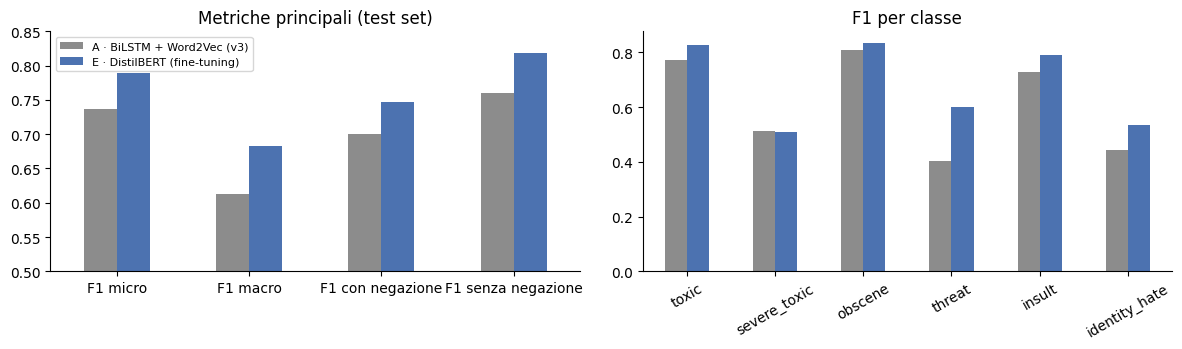

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
comp[['F1 micro', 'F1 macro', 'F1 con negazione', 'F1 senza negazione']].T.plot.bar(ax=axes[0], color=['#8C8C8C', '#4C72B0'], rot=0)
axes[0].set_ylim(0.5, 0.85); axes[0].set_title('Metriche principali (test set)'); axes[0].legend(fontsize=8)
comp[[f'F1 {l}' for l in LABEL_COLUMNS]].T.plot.bar(ax=axes[1], color=['#8C8C8C', '#4C72B0'], rot=30, legend=False)
axes[1].set_title('F1 per classe'); axes[1].set_xticklabels(LABEL_COLUMNS)
for ax in axes: sns.despine(ax=ax)
plt.tight_layout(); plt.show()

### Frasi di prova (stesse della v3)

In [8]:
probe = [
    "I don't find this offensive at all.",
    "This is not stupid, it is a good idea.",
    "You are not an idiot, you just made a mistake.",
    "You are an idiot.",
    "You are an idi0t.",
    "you are such a stupiddd moron",
    "f*ck you and your edits",
    "Thanks for fixing the references.",
]
@torch.no_grad()
def predict_texts(sentences):
    model.eval()
    enc = tokenizer(sentences, truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(DEVICE)
    return torch.sigmoid(model(**enc).logits.float()).cpu().numpy()

probe_df = pd.DataFrame(predict_texts(probe), columns=LABEL_COLUMNS)
probe_df.insert(0, 'frase', probe)
probe_df['etichette'] = [[l for l, t in zip(LABEL_COLUMNS, thr) if r[l] >= t] for _, r in probe_df.iterrows()]
display(probe_df.style.format('{:.2f}', subset=LABEL_COLUMNS)
        .background_gradient(subset=LABEL_COLUMNS, cmap='Reds', vmin=0, vmax=1))

,frase,toxic,severe_toxic,obscene,threat,insult,identity_hate,etichette
0,I don't find this offensive at all.,0.00,0.00,0.00,0.00,0.00,0.00,[]
1,"This is not stupid, it is a good idea.",0.88,0.00,0.05,0.00,0.08,0.00,['toxic']
2,"You are not an idiot, you just made a mistake.",0.97,0.00,0.23,0.00,0.82,0.00,"['toxic', 'insult']"
3,You are an idiot.,0.99,0.07,0.79,0.00,0.96,0.02,"['toxic', 'obscene', 'insult']"
4,You are an idi0t.,0.79,0.00,0.02,0.00,0.25,0.00,['toxic']
5,you are such a stupiddd moron,1.00,0.06,0.75,0.00,0.96,0.04,"['toxic', 'obscene', 'insult']"
6,f*ck you and your edits,1.00,0.41,0.99,0.01,0.60,0.01,"['toxic', 'severe_toxic', 'obscene', 'insult']"
7,Thanks for fixing the references.,0.00,0.00,0.00,0.00,0.00,0.00,[]


## 5. Salvataggio su Drive (modello pronto per la demo)

In [9]:
with open(os.path.join(BEST_DIR, 'thresholds.json'), 'w') as f:
    json.dump(dict(zip(LABEL_COLUMNS, map(float, thr))), f, indent=2)
pd.DataFrame(history).to_csv(os.path.join(BEST_DIR, 'training_history.csv'), index=False)
comp.to_csv(os.path.join(BEST_DIR, 'confronto_bilstm_distilbert.csv'))
if IN_COLAB:
    shutil.copytree(BEST_DIR, DRIVE_FOLDER, dirs_exist_ok=True)
print('Salvato in', DRIVE_FOLDER if IN_COLAB else BEST_DIR, '→', sorted(os.listdir(BEST_DIR)))

Salvato in /content/drive/MyDrive/modelli_addestrati/filtro_anti_haters_v4_distilbert → ['config.json', 'confronto_bilstm_distilbert.csv', 'model.safetensors', 'thresholds.json', 'tokenizer.json', 'tokenizer_config.json', 'training_history.csv']


## 6. Conclusioni

| | BiLSTM + Word2Vec (v3) | **DistilBERT** | Δ |
|---|---|---|---|
| ROC AUC | 0.980 | **0.992** | +0.012 |
| F1 micro | 0.736 | **0.790** | +5.4 punti |
| F1 macro | 0.613 | **0.683** | +7.0 punti |
| F1 con negazione | 0.700 | **0.747** | +4.7 punti |
| F1 `threat` | 0.405 | **0.602** | +19.7 punti |
| F1 `identity_hate` | 0.445 | **0.536** | +9.1 punti |

- **Il modello contestuale migliora su tutte le metriche**, in modo netto sulle classi rare (`threat`, `identity_hate`), dove la BiLSTM
  aveva pochi esempi da cui imparare: DistilBERT parte da una conoscenza della lingua acquisita nel pre-addestramento.
- **Negazioni:** *"I don't find this offensive at all"* passa da 0.35 (BiLSTM) a **0.00**. Restano difficili le frasi con un insulto
  esplicito negato (*"You are not an idiot"*): il divario con/senza negazione si riduce ma non sparisce (0.75 contro 0.82).
- **Costo:** 15 minuti di fine-tuning su T4 (2 epoche), contro ~20 minuti della BiLSTM più ~25 di preparazione degli embedding.
  Il modello pesa ~255 MB ed è pronto per una demo su Hugging Face Spaces.
- `severe_toxic` resta la classe più difficile per entrambi (F1 ~0.51): il confine con `toxic` è soggettivo anche per gli annotatori.

*Nota: la quota di commenti "con negazione" (54.0% contro 52.3% della v3) differisce leggermente perché qui il controllo è fatto
sul testo grezzo invece che su quello pulito; le metriche principali sono calcolate sullo stesso identico test set.*
